# Elamite NLP Experiments v3: Boosting Unicode Cuneiform
## ACL 2026 Short Paper Pipeline

**Changes from v2:**
- Tuned Unicode fastText n-gram range (1→5 instead of 1→3)
- Added **character-level BiLSTM** classifier (replaces SVM as primary)
- Added **character n-gram logistic regression** baseline
- Kept k-NN as simple baseline for comparison
- Better t-SNE with local cluster analysis

**Sections 1–2 (data + Exp 1) and Section 3 (Exp 2) are identical to v2 except for the n-gram tuning.**
**Section 4 (Exp 3) is completely rebuilt.**

In [1]:
# ============================================================
# 0. SETUP & DEPENDENCIES
# ============================================================
!pip install -q gensim scikit-learn matplotlib seaborn pandas openpyxl regex umap-learn imbalanced-learn torch

import pandas as pd
import numpy as np
import regex as re
import json, os
from collections import Counter, defaultdict

from gensim.models import FastText
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    classification_report, f1_score, silhouette_score, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Setup complete. Device: {device}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.8 MB/s eta 0:00:00
Setup complete. Device: cuda


In [2]:
# ============================================================
# 0b. MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = 'data/'
DICT_PATH = BASE_PATH + 'Elamite_Lemma-base-draft.xlsx'
NASU_PATH = BASE_PATH + 'UnTN-Nasu texts Word-level.csv'
UNMATCHED_PATH_1 = BASE_PATH + 'unmatchednew_AAedit - unmatchednew.csv'
UNMATCHED_PATH_2 = BASE_PATH + 'unmatchednew - solonew.csv'

Mounted at /content/drive


---
## Section 1: Data Loading & Preprocessing
*(Identical to v2 — your original pipeline)*

In [3]:
# ============================================================
# 1a. LOAD DICTIONARY
# ============================================================
all_sheets = pd.read_excel(DICT_PATH, sheet_name=None)
target_tabs = ['ADJ', 'Noun', 'Verb', 'other', 'PN', 'PN-hyp', 'GN', 'DN', 'Magic']
columns_to_keep = [
    'transliteration', 'sorting', 'period', 'base',
    'logogram', 'morpheme_1', 'morpheme_2', 'morpheme_3',
    'sense_hk', 'certainty-weight_hk', 'sense_hk_qid',
    'certainty-weight_MEGA', 'sense_MEGA_qid', 'POS', 'number', 'person'
]
combined_list = []
for name in target_tabs:
    if name in all_sheets:
        df = all_sheets[name]
        df['category'] = name
        existing_cols = [c for c in columns_to_keep if c in df.columns]
        combined_list.append(df[existing_cols + ['category']])
final_dictionary = pd.concat(combined_list, ignore_index=True)
print(f'Dictionary: {len(final_dictionary)} entries')
print(f'POS: {final_dictionary["category"].value_counts().to_dict()}')

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Dictionary: 15601 entries
POS: {'PN': 6060, 'Noun': 4306, 'GN': 1756, 'Verb': 1711, 'other': 787, 'ADJ': 614, 'DN': 337, 'PN-hyp': 30}


In [4]:
# ============================================================
# 1b. SIGN LISTS & UNICODE MAPPING
# ============================================================
sign_list = pd.read_json(
    'https://raw.githubusercontent.com/situx/Nuolenna/master/sign_list.json', orient='index'
)
sign_list.columns = ['unicode']
sign_list['sign'] = sign_list.index.tolist()
sign_list = sign_list[['sign', 'unicode']].reset_index(drop=True)

akkademia = pd.read_csv(
    'https://raw.githubusercontent.com/gaigutherz/Akkademia/master/cuneiform_to_unicode_fixed.csv'
)
concatenated = pd.merge(sign_list, akkademia, on=['sign', 'unicode'], how='outer', indicator=True)

unmatched = pd.read_csv(UNMATCHED_PATH_1)
unmatched2 = pd.read_csv(UNMATCHED_PATH_2)
unmatched = unmatched[['unmatched_sign','use']].dropna()
unmatched2 = unmatched2[['value', 'SIGN']].dropna()
manual_dict = dict(zip(unmatched['unmatched_sign'], unmatched['use']))
manual_dict2 = dict(zip(unmatched2['value'].str.strip("[]' "), unmatched2['SIGN']))

unicode_dict = dict(zip(concatenated['sign'], concatenated['unicode']))
unicode_dict.update(manual_dict)
unicode_dict.update(manual_dict2)
print(f'Sign mappings: {len(unicode_dict)}')

Sign mappings: 18272


In [5]:
# ============================================================
# 1c. FIRST-PASS PREPROCESSING (your original pipeline)
# ============================================================
to_unicode = final_dictionary.copy()
to_unicode['transliteration original'] = to_unicode['transliteration']
to_unicode['transliteration'] = to_unicode['transliteration'].astype(str).fillna('')

# Hyphen → space
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace('-', ' ')
# Remove special chars; dot → space
for ch in ['_', '[', ']', '*', '!', '?', '/', ',', ':', ';', '^', '`']:
    to_unicode['transliteration'] = to_unicode['transliteration'].str.replace(ch, '', regex=False)
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace('.', ' ', regex=False)
# Lowercase
to_unicode['transliteration'] = to_unicode['transliteration'].str.lower()
# Tilde removal with …… placeholder
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace(r'~.*?……', '……', regex=True)
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace('X', '', regex=False)
to_unicode['transliteration'] = to_unicode['transliteration'].str.replace('……', ' ', regex=False)

# First-pass Unicode conversion
def replace_with_unicode(text):
    return ' '.join([unicode_dict.get(s, s) for s in text.split()])

to_unicode['unicode'] = to_unicode['transliteration'].apply(replace_with_unicode)
to_unicode['roman'] = to_unicode['unicode'].apply(
    lambda x: any(bool(re.search(r'\p{Latin}', w)) for w in x.split())
)
print(f'After first pass: {(~to_unicode["roman"]).sum()} / {len(to_unicode)} clean '
      f'({(~to_unicode["roman"]).sum()/len(to_unicode)*100:.1f}%)')

After first pass: 13302 / 15601 clean (85.3%)


In [6]:
# ============================================================
# 1d. SECOND-PASS CONVERSION (your Cell 27)
# ============================================================
unicode_dict_v2 = dict(zip(concatenated['sign'].astype(str), concatenated['unicode'].astype(str)))
unicode_dict_v2.update(manual_dict)
unicode_dict_v2.update(manual_dict2)

def normalize_for_unmatched_pass(s):
    if pd.isna(s): return ""
    s = str(s)
    s = re.sub(r"\(\s*md\s*\)", " m d ", s)
    s = re.sub(r"[.,:;!?()\[\]{}<>\\\"\"\"''/\\|*^`~]", " ", s)
    s = re.sub(r"[-\u2013\u2014]", " ", s)
    s = re.sub(r"([A-Za-z])(\d)([A-Za-z])", r"\1\2 \3", s)
    s = re.sub(r"(\d)([A-Za-z])", r"\1 \2", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def final_unmatched_conversion_pass(unicode_text):
    txt = normalize_for_unmatched_pass(unicode_text)
    tokens = txt.split()
    out, still_unmatched = [], []
    for tok in tokens:
        if tok == "md" and "m" in unicode_dict_v2 and "d" in unicode_dict_v2 and "md" not in unicode_dict_v2:
            out.append(unicode_dict_v2["m"]); out.append(unicode_dict_v2["d"]); continue
        if tok in unicode_dict_v2:
            out.append(unicode_dict_v2[tok])
        else:
            out.append(tok)
            if re.search(r'\p{Latin}', tok): still_unmatched.append(tok)
    return " ".join(out), still_unmatched

tmp = to_unicode['unicode'].apply(final_unmatched_conversion_pass)
to_unicode['transliteration'] = to_unicode['transliteration original'].apply(normalize_for_unmatched_pass)
to_unicode['roman'] = tmp.apply(lambda x: len(x[1]) > 0)
to_unicode['unicode'] = tmp.apply(lambda x: x[0])

dict_clean = to_unicode[to_unicode['roman'] == False].copy()
print(f'Clean entries: {len(dict_clean)} / {len(to_unicode)} ({len(dict_clean)/len(to_unicode)*100:.1f}%)')

Clean entries: 13383 / 15601 (85.8%)


In [7]:
# ============================================================
# 1e. THREE REPRESENTATIONS
# ============================================================
dict_clean['repr_latin'] = dict_clean['transliteration']
dict_clean['repr_unicode'] = dict_clean['unicode']
dict_clean['repr_unicode_nospace'] = dict_clean['unicode'].str.replace(' ', '')

print('=== Samples ===')
for _, r in dict_clean[['transliteration original','repr_latin','repr_unicode','category']].head(5).iterrows():
    print(f"  {r['transliteration original']:30s} → Latin: {r['repr_latin']:25s} Unicode: {r['repr_unicode']:30s} [{r['category']}]")

=== Samples ===
  a-a                            → Latin: a a                       Unicode: 𒀀 𒀀                            [ADJ]
  h.hi-bat-tin-na                → Latin: h hi bat tin na           Unicode: 𒀸 𒄭 𒁁 𒁷 𒈾                      [ADJ]
  v.ha-ak-qa-man-nu-iš-ši-ya     → Latin: v ha ak qa man nu iš ši ya Unicode: 𒁹 𒄩 𒀝 𒋡 𒌋𒌋 𒉡 𒅖 𒅆 𒉿             [ADJ]
  am-mín-nu                      → Latin: am mín nu                 Unicode: 𒄠 𒊩 𒉡                          [ADJ]
  te-man?-na?-na                 → Latin: te man na na              Unicode: 𒋼 𒌋𒌋 𒈾 𒈾                       [ADJ]


In [8]:
# ============================================================
# 1f. NASU CORPUS
# ============================================================
nasu_df = pd.read_csv(NASU_PATH)
nasu_df['translit_clean'] = nasu_df['transliteration'].apply(normalize_for_unmatched_pass)

def convert_nasu_to_unicode(text):
    if pd.isna(text) or text == '': return ''
    return final_unmatched_conversion_pass(replace_with_unicode(text))[0]

nasu_df['unicode'] = nasu_df['translit_clean'].apply(convert_nasu_to_unicode)
docs_latin = nasu_df.groupby('id_text')['translit_clean'].apply(lambda x: ' '.join(x.dropna())).tolist()
docs_unicode = nasu_df.groupby('id_text')['unicode'].apply(lambda x: ' '.join(x.dropna())).tolist()
print(f'Nasu: {len(nasu_df)} tokens, {len(docs_latin)} documents')

Nasu: 2582 tokens, 85 documents


---
## Section 2: Experiment 1 — Embedding Comparison
**Change: Unicode n-gram range widened to 1–5**

In [9]:
# ============================================================
# 2a. TRAINING CORPORA
# ============================================================
corpus_latin = [e.split() for e in dict_clean['repr_latin'].tolist() if e]
corpus_latin += [d.split() for d in docs_latin if d]
corpus_unicode = [e.split() for e in dict_clean['repr_unicode'].tolist() if e]
corpus_unicode += [d.split() for d in docs_unicode if d]

print(f'Latin:   {len(corpus_latin)} sents, {sum(len(s) for s in corpus_latin)} tokens')
print(f'Unicode: {len(corpus_unicode)} sents, {sum(len(s) for s in corpus_unicode)} tokens')

Latin:   13468 sents, 67545 tokens
Unicode: 13468 sents, 67142 tokens


In [10]:
# ============================================================
# 2b. TRAIN FASTTEXT — Unicode gets wider n-gram range
# ============================================================
DIM = 100; WIN = 5; EPOCHS = 50

print('Training Latin fastText (char n-gram 2-5)...')
model_latin = FastText(
    sentences=corpus_latin, vector_size=DIM, window=WIN,
    min_count=1, epochs=EPOCHS, seed=SEED, min_n=2, max_n=5, sg=1
)
print(f'  Vocab: {len(model_latin.wv)}')

# KEY CHANGE: wider n-gram range for Unicode (1-5 instead of 1-3)
# This lets the model learn longer sign-sequence patterns
print('Training Unicode fastText (char n-gram 1-5)...')
model_unicode = FastText(
    sentences=corpus_unicode, vector_size=DIM, window=WIN,
    min_count=1, epochs=EPOCHS, seed=SEED, min_n=1, max_n=5, sg=1
)
print(f'  Vocab: {len(model_unicode.wv)}')

Training Latin fastText (char n-gram 2-5)...
  Vocab: 660
Training Unicode fastText (char n-gram 1-5)...
  Vocab: 294


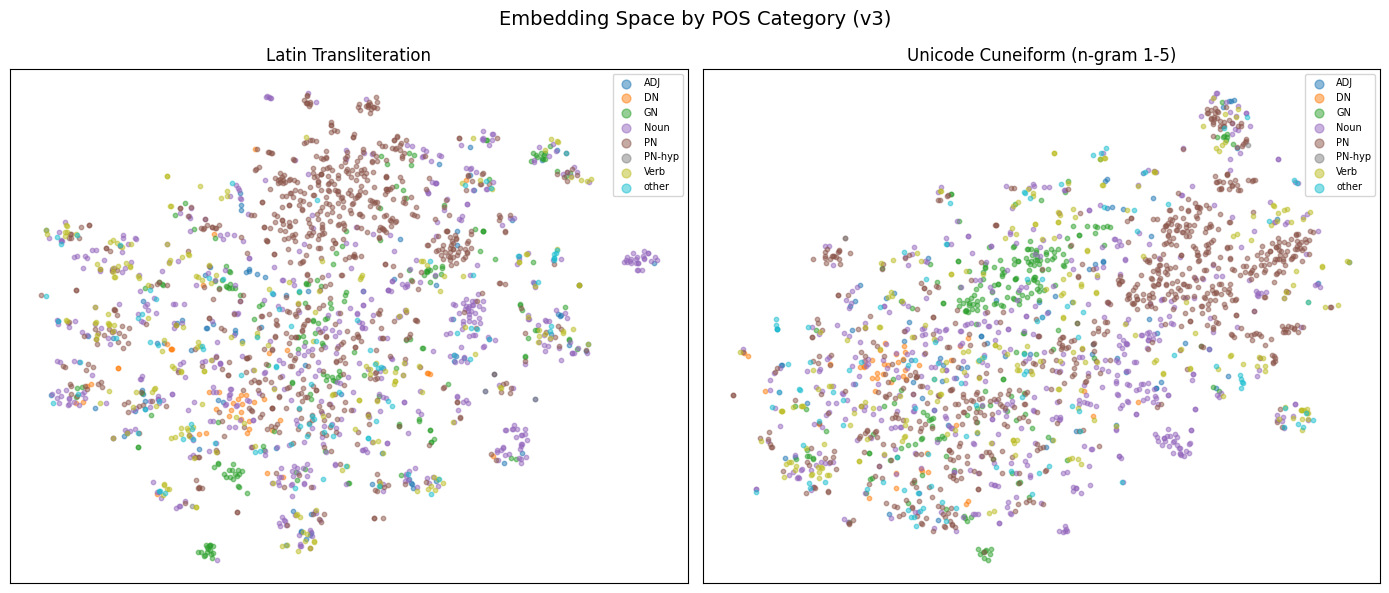

In [11]:
# ============================================================
# 2c. t-SNE + LOCAL CLUSTER ANALYSIS
# ============================================================
def plot_tsne_by_pos(model, repr_col, title, ax):
    vectors, labels = [], []
    for _, row in dict_clean.iterrows():
        word = row[repr_col]
        if pd.isna(word) or word == '' or word not in model.wv: continue
        vectors.append(model.wv[word]); labels.append(row['category'])
    if len(vectors) < 10:
        ax.set_title(f'{title} (insufficient)'); return
    vectors = np.array(vectors)
    max_pts = 2000
    if len(vectors) > max_pts:
        idx = np.random.choice(len(vectors), max_pts, replace=False)
        vectors = vectors[idx]; labels = [labels[i] for i in idx]
    reduced = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(vectors)-1)).fit_transform(vectors)
    pos_cats = sorted(set(labels))
    colors = plt.cm.tab10(np.linspace(0, 1, len(pos_cats)))
    for i, cat in enumerate(pos_cats):
        mask = [l == cat for l in labels]
        pts = reduced[mask]
        if len(pts): ax.scatter(pts[:,0], pts[:,1], c=[colors[i]], label=cat, alpha=0.5, s=10)
    ax.set_title(title, fontsize=12); ax.legend(fontsize=7, markerscale=2)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_tsne_by_pos(model_latin, 'repr_latin', 'Latin Transliteration', axes[0])
plot_tsne_by_pos(model_unicode, 'repr_unicode', 'Unicode Cuneiform (n-gram 1-5)', axes[1])
plt.suptitle('Embedding Space by POS Category (v3)', fontsize=14)
plt.tight_layout(); plt.savefig('exp1_tsne_v3.png', dpi=150, bbox_inches='tight'); plt.show()

In [12]:
# ============================================================
# 2d. SILHOUETTE + MORPHEME COHERENCE + PER-CLASS SILHOUETTE
# ============================================================
def compute_metrics(model, repr_col, label=''):
    vectors, labels = [], []
    for _, row in dict_clean.iterrows():
        word = row[repr_col]
        if pd.isna(word) or word == '' or word not in model.wv: continue
        vectors.append(model.wv[word]); labels.append(row['category'])
    vectors = np.array(vectors); labels = np.array(labels)

    # Subsample
    if len(vectors) > 3000:
        idx = np.random.choice(len(vectors), 3000, replace=False)
        vectors = vectors[idx]; labels = labels[idx]

    # Global silhouette
    sil = silhouette_score(vectors, labels, metric='cosine')
    print(f'  {label} Global silhouette: {sil:.4f}')

    # Per-class silhouette
    from sklearn.metrics import silhouette_samples
    sil_samples = silhouette_samples(vectors, labels, metric='cosine')
    print(f'  Per-class silhouette:')
    per_class = {}
    for cat in sorted(set(labels)):
        mask = labels == cat
        s = sil_samples[mask].mean()
        per_class[cat] = s
        print(f'    {cat:10s}: {s:.4f} (n={mask.sum()})')

    # Morpheme coherence
    suffix_data = dict_clean[['repr_latin','repr_unicode','morpheme_1']].dropna(subset=['morpheme_1'])
    coh_scores = []
    for morph, group in suffix_data.groupby('morpheme_1'):
        if len(group) < 3: continue
        vecs = [model.wv[w] for w in group[repr_col] if w in model.wv]
        if len(vecs) < 3: continue
        vecs = np.array(vecs)
        sim = cosine_similarity(vecs)
        n = len(vecs)
        coh_scores.append((sim.sum() - n) / (n*(n-1)))
    coh = np.mean(coh_scores)
    print(f'  Morpheme coherence: {coh:.4f} ({len(coh_scores)} groups)')
    return sil, per_class, coh

print('=== Latin ===')
sil_l, pc_l, coh_l = compute_metrics(model_latin, 'repr_latin', 'Latin')
print('\n=== Unicode ===')
sil_u, pc_u, coh_u = compute_metrics(model_unicode, 'repr_unicode', 'Unicode')

# Per-class comparison
print('\n=== Per-class silhouette: Unicode vs Latin ===')
for cat in sorted(pc_l.keys()):
    diff = pc_u.get(cat, 0) - pc_l.get(cat, 0)
    winner = 'Unicode' if diff > 0 else 'Latin'
    print(f'  {cat:10s}: Latin={pc_l[cat]:.4f}  Unicode={pc_u.get(cat,0):.4f}  ({winner}, Δ={diff:+.4f})')

=== Latin ===
  Latin Global silhouette: -0.0342
  Per-class silhouette:
    ADJ       : -0.0778 (n=128)
    DN        : 0.1391 (n=71)
    GN        : -0.0550 (n=317)
    Noun      : -0.1068 (n=845)
    PN        : 0.0437 (n=1151)
    PN-hyp    : 0.2326 (n=3)
    Verb      : -0.0735 (n=326)
    other     : -0.1368 (n=159)
  Morpheme coherence: 0.6377 (39 groups)

=== Unicode ===
  Unicode Global silhouette: -0.0612
  Per-class silhouette:
    ADJ       : -0.1014 (n=104)
    DN        : 0.1586 (n=63)
    GN        : 0.1121 (n=344)
    Noun      : -0.1350 (n=880)
    PN        : -0.0306 (n=1107)
    PN-hyp    : -0.0344 (n=4)
    Verb      : -0.1293 (n=354)
    other     : -0.1599 (n=144)
  Morpheme coherence: 0.6483 (39 groups)

=== Per-class silhouette: Unicode vs Latin ===
  ADJ       : Latin=-0.0778  Unicode=-0.1014  (Latin, Δ=-0.0236)
  DN        : Latin=0.1391  Unicode=0.1586  (Unicode, Δ=+0.0195)
  GN        : Latin=-0.0550  Unicode=0.1121  (Unicode, Δ=+0.1671)
  Noun      : Latin=

---
## Section 3: Experiment 2 — Word Boundary Inference
*(Same as v2)*

In [13]:
# ============================================================
# 3. WORD BOUNDARY INFERENCE (same as v2)
# ============================================================
def get_boundary_positions(text):
    positions, pos = [], 0
    for ch in text:
        if ch == ' ': positions.append(pos)
        else: pos += 1
    return positions

gold_data = []
for doc in docs_unicode:
    if doc and len(doc.split()) > 2:
        b = get_boundary_positions(doc)
        c = doc.replace(' ', '')
        if len(c) > 3 and b: gold_data.append({'segmented':doc, 'continuous':c, 'boundaries':b})

def build_bigram_model(texts):
    bi, uni = Counter(), Counter()
    for t in texts:
        chars = [c for c in t if c != ' ']
        for c in chars: uni[c] += 1
        for i in range(len(chars)-1): bi[(chars[i],chars[i+1])] += 1
    return bi, uni

def predict_tp(text, bi, uni, thresh):
    chars = list(text)
    return [i+1 for i in range(len(chars)-1) if bi.get((chars[i],chars[i+1]),0)/uni.get(chars[i],1) < thresh]

def boundary_f1(gold, pred):
    g, p = set(gold), set(pred)
    if not p: return 0,0,0
    tp = len(g&p)
    pr = tp/len(p); rc = tp/len(g) if g else 0
    return pr, rc, 2*pr*rc/(pr+rc) if (pr+rc) else 0

train_texts = dict_clean['repr_unicode'].dropna().tolist()
bigrams, unigrams = build_bigram_model(train_texts)

# TP sweep
tp_results = []
for t in np.arange(0.1, 0.9, 0.05):
    scores = [boundary_f1(d['boundaries'], predict_tp(d['continuous'], bigrams, unigrams, t)) for d in gold_data]
    tp_results.append({'threshold':t, 'precision':np.mean([s[0] for s in scores]),
                       'recall':np.mean([s[1] for s in scores]), 'f1':np.mean([s[2] for s in scores])})
tp_df = pd.DataFrame(tp_results)
best_tp = tp_df.loc[tp_df['f1'].idxmax()]
print(f'TP: threshold={best_tp["threshold"]:.2f}  P={best_tp["precision"]:.3f}  R={best_tp["recall"]:.3f}  F1={best_tp["f1"]:.3f}')

# BPE
def learn_bpe(texts, n_merges=300):
    vocab = Counter()
    for t in texts:
        for w in t.split():
            chars = list(w)
            if chars: vocab[' '.join(chars)] += 1
    merges = []
    for _ in range(n_merges):
        pairs = Counter()
        for w, f in vocab.items():
            s = w.split()
            for j in range(len(s)-1): pairs[(s[j],s[j+1])] += f
        if not pairs: break
        bp = max(pairs, key=pairs.get); merges.append(bp)
        vocab = {w.replace(' '.join(bp),''.join(bp)):f for w,f in vocab.items()}
    return merges

def segment_bpe(text, merges):
    s = list(text)
    for p in merges:
        i = 0
        while i < len(s)-1:
            if s[i]==p[0] and s[i+1]==p[1]: s[i]=p[0]+p[1]; s.pop(i+1)
            else: i+=1
    return s

bpe_merges = learn_bpe(train_texts)
bpe_scores = []
for d in gold_data:
    segs = segment_bpe(d['continuous'], bpe_merges)
    pb = []; pos = 0
    for seg in segs[:-1]: pos += len(seg); pb.append(pos)
    bpe_scores.append(boundary_f1(d['boundaries'], pb))
print(f'BPE: P={np.mean([s[0] for s in bpe_scores]):.3f}  R={np.mean([s[1] for s in bpe_scores]):.3f}  '
      f'F1={np.mean([s[2] for s in bpe_scores]):.3f}')

TP: threshold=0.35  P=0.987  R=1.000  F1=0.993
BPE: P=0.989  R=0.995  F1=0.991


---
## Section 4: Experiment 3 — POS Classification (REBUILT)

**Models:**
1. Character n-gram logistic regression (baseline)
2. k-NN on fastText embeddings (simple baseline)
3. **Character-level BiLSTM** (primary model)

This replaces SVM entirely.

In [14]:
# ============================================================
# 4a. PREPARE DATA
# ============================================================
min_examples = 20
pos_counts = dict_clean['category'].value_counts()
valid_pos = pos_counts[pos_counts >= min_examples].index.tolist()
clf_data = dict_clean[dict_clean['category'].isin(valid_pos)].copy()
print(f'Classes: {clf_data["category"].value_counts().to_dict()}')

# Encode labels
le = LabelEncoder()
le.fit(clf_data['category'])
n_classes = len(le.classes_)
print(f'{n_classes} classes: {list(le.classes_)}')

Classes: {'PN': 4992, 'Noun': 3852, 'Verb': 1500, 'GN': 1493, 'other': 687, 'ADJ': 538, 'DN': 301, 'PN-hyp': 20}
8 classes: ['ADJ', 'DN', 'GN', 'Noun', 'PN', 'PN-hyp', 'Verb', 'other']


In [15]:
# ============================================================
# 4b. MODEL 1: CHARACTER N-GRAM LOGISTIC REGRESSION
# ============================================================
# This is a strong feature-engineering baseline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def ngram_classify(texts, labels, name):
    # Use character n-grams as features
    vectorizer = CountVectorizer(analyzer='char', ngram_range=(1,4))
    X = vectorizer.fit_transform(texts)
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED, C=1.0)
    scores = cross_val_score(clf, X, labels, cv=cv, scoring='f1_macro')
    print(f'  {name}: F1 = {scores.mean():.3f} ± {scores.std():.3f}')

    # Detailed report
    y_pred = cross_val_predict(clf, X, labels, cv=cv)
    print(classification_report(labels, y_pred, zero_division=0))
    return scores.mean(), y_pred

print('=== Char n-gram Logistic Regression ===')
latin_texts = clf_data['repr_latin'].fillna('').tolist()
unicode_texts = clf_data['repr_unicode'].fillna('').tolist()
labels = clf_data['category'].tolist()

print('--- Latin ---')
ngram_f1_l, ngram_pred_l = ngram_classify(latin_texts, labels, 'Latin')
print('--- Unicode ---')
ngram_f1_u, ngram_pred_u = ngram_classify(unicode_texts, labels, 'Unicode')

=== Char n-gram Logistic Regression ===
--- Latin ---
  Latin: F1 = 0.567 ± 0.008
              precision    recall  f1-score   support

         ADJ       0.33      0.50      0.40       538
          DN       0.54      0.72      0.62       301
          GN       0.77      0.82      0.79      1493
        Noun       0.75      0.62      0.68      3852
          PN       0.89      0.82      0.85      4992
      PN-hyp       0.05      0.15      0.08        20
        Verb       0.67      0.76      0.71      1500
       other       0.34      0.55      0.42       687

    accuracy                           0.72     13383
   macro avg       0.54      0.62      0.57     13383
weighted avg       0.75      0.72      0.73     13383

--- Unicode ---
  Unicode: F1 = 0.582 ± 0.013
              precision    recall  f1-score   support

         ADJ       0.40      0.49      0.44       538
          DN       0.58      0.74      0.65       301
          GN       0.79      0.83      0.81      1493
    

In [16]:
# ============================================================
# 4c. MODEL 2: k-NN ON FASTTEXT EMBEDDINGS
# ============================================================
def build_features(data, model, repr_col):
    X, y = [], []
    for _, row in data.iterrows():
        word = row[repr_col]
        if pd.isna(word) or word == '': continue
        try:
            X.append(model.wv[word]); y.append(row['category'])
        except KeyError: continue
    return np.array(X), np.array(y)

X_l, y_l = build_features(clf_data, model_latin, 'repr_latin')
X_u, y_u = build_features(clf_data, model_unicode, 'repr_unicode')

min_class_l = min(Counter(y_l).values())
min_class_u = min(Counter(y_u).values())

print('=== k-NN on fastText embeddings ===')
for k in [5, 10]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    smote_k = min(5, min_class_l - 1)
    if smote_k >= 1:
        pipe_l = ImbPipeline([('smote', SMOTE(random_state=SEED, k_neighbors=smote_k)), ('clf', knn)])
    else:
        pipe_l = knn
    s_l = cross_val_score(pipe_l, X_l, y_l, cv=cv, scoring='f1_macro')

    knn2 = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    smote_k2 = min(5, min_class_u - 1)
    if smote_k2 >= 1:
        pipe_u = ImbPipeline([('smote', SMOTE(random_state=SEED, k_neighbors=smote_k2)), ('clf', knn2)])
    else:
        pipe_u = knn2
    s_u = cross_val_score(pipe_u, X_u, y_u, cv=cv, scoring='f1_macro')

    print(f'  k={k}: Latin={s_l.mean():.3f}±{s_l.std():.3f}  Unicode={s_u.mean():.3f}±{s_u.std():.3f}')

=== k-NN on fastText embeddings ===
  k=5: Latin=0.447±0.011  Unicode=0.446±0.012
  k=10: Latin=0.421±0.010  Unicode=0.423±0.010


In [17]:
# ============================================================
# 4d. MODEL 3: CHARACTER-LEVEL BiLSTM
# ============================================================

class CharVocab:
    """Build a character vocabulary from texts."""
    def __init__(self):
        self.char2idx = {'<pad>': 0, '<unk>': 1}
        self.idx2char = {0: '<pad>', 1: '<unk>'}

    def build(self, texts):
        for text in texts:
            for ch in text:
                if ch not in self.char2idx:
                    idx = len(self.char2idx)
                    self.char2idx[ch] = idx
                    self.idx2char[idx] = ch
        return self

    def encode(self, text, max_len=None):
        ids = [self.char2idx.get(ch, 1) for ch in text]
        if max_len:
            ids = ids[:max_len] + [0] * max(0, max_len - len(ids))
        return ids

    def __len__(self):
        return len(self.char2idx)


class ElamiteDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = self.vocab.encode(self.texts[idx], self.max_len)
        return torch.tensor(ids, dtype=torch.long), self.labels[idx]


class CharBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes, n_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                           bidirectional=True, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        mask = (x != 0).float()  # (batch, seq_len)
        emb = self.embedding(x)  # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(emb)  # (batch, seq_len, hidden*2)

        # Masked mean pooling
        mask_expanded = mask.unsqueeze(-1)  # (batch, seq_len, 1)
        summed = (lstm_out * mask_expanded).sum(dim=1)
        lengths = mask.sum(dim=1, keepdim=True).clamp(min=1)
        pooled = summed / lengths  # (batch, hidden*2)

        return self.fc(self.dropout(pooled))


print('BiLSTM model defined.')
print(f'Device: {device}')

BiLSTM model defined.
Device: cuda


In [18]:
# ============================================================
# 4e. TRAIN & EVALUATE BiLSTM WITH CROSS-VALIDATION
# ============================================================
EMBED_DIM = 64
HIDDEN_DIM = 128
N_LAYERS = 2
DROPOUT = 0.3
LR = 0.001
BATCH_SIZE = 64
N_EPOCHS = 30


def train_bilstm_cv(texts, labels_str, repr_name, n_splits=5):
    """Train BiLSTM with stratified k-fold CV."""
    # Compute class weights for loss function
    label_counts = Counter(labels_str)
    total = sum(label_counts.values())
    n_cls = len(label_counts)
    class_weights = {}
    for cls, count in label_counts.items():
        class_weights[cls] = total / (n_cls * count)

    labels_encoded = le.transform(labels_str)
    max_len = min(100, max(len(t) for t in texts))

    # Build vocab
    vocab = CharVocab().build(texts)

    # Compute weight tensor
    weight_tensor = torch.zeros(n_classes)
    for cls_name, w in class_weights.items():
        weight_tensor[le.transform([cls_name])[0]] = w
    weight_tensor = weight_tensor.to(device)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    all_preds = np.zeros(len(texts), dtype=int)
    fold_f1s = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(texts, labels_encoded)):
        train_texts = [texts[i] for i in train_idx]
        val_texts = [texts[i] for i in val_idx]
        train_labels = labels_encoded[train_idx]
        val_labels = labels_encoded[val_idx]

        train_ds = ElamiteDataset(train_texts, train_labels, vocab, max_len)
        val_ds = ElamiteDataset(val_texts, val_labels, vocab, max_len)
        train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE)

        model = CharBiLSTM(len(vocab), EMBED_DIM, HIDDEN_DIM, n_classes, N_LAYERS, DROPOUT).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = nn.CrossEntropyLoss(weight=weight_tensor)

        # Train
        best_f1 = 0
        for epoch in range(N_EPOCHS):
            model.train()
            for batch_x, batch_y in train_dl:
                batch_x = batch_x.to(device)
                batch_y = torch.tensor(batch_y, dtype=torch.long).to(device)
                optimizer.zero_grad()
                logits = model(batch_x)
                loss = criterion(logits, batch_y)
                loss.backward()
                optimizer.step()

        # Evaluate
        model.eval()
        preds = []
        with torch.no_grad():
            for batch_x, batch_y in val_dl:
                batch_x = batch_x.to(device)
                logits = model(batch_x)
                preds.extend(logits.argmax(dim=1).cpu().numpy())

        preds = np.array(preds)
        all_preds[val_idx] = preds
        fold_f1 = f1_score(val_labels, preds, average='macro', zero_division=0)
        fold_f1s.append(fold_f1)
        print(f'  Fold {fold+1}: F1 = {fold_f1:.3f}')

    mean_f1 = np.mean(fold_f1s)
    print(f'  {repr_name} BiLSTM Mean F1: {mean_f1:.3f} ± {np.std(fold_f1s):.3f}')

    # Full report
    print(classification_report(labels_encoded, all_preds,
          target_names=le.classes_, zero_division=0))

    return mean_f1, all_preds


print('=== BiLSTM: Latin ===')
bilstm_f1_l, bilstm_pred_l = train_bilstm_cv(
    clf_data['repr_latin'].fillna('').tolist(),
    clf_data['category'].tolist(),
    'Latin'
)

print('\n=== BiLSTM: Unicode ===')
bilstm_f1_u, bilstm_pred_u = train_bilstm_cv(
    clf_data['repr_unicode'].fillna('').tolist(),
    clf_data['category'].tolist(),
    'Unicode'
)

=== BiLSTM: Latin ===


/tmp/ipykernel_25787/1082456838.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch_y = torch.tensor(batch_y, dtype=torch.long).to(device)


  Fold 1: F1 = 0.575


/tmp/ipykernel_25787/1082456838.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch_y = torch.tensor(batch_y, dtype=torch.long).to(device)


  Fold 2: F1 = 0.578


...

  Fold 3: F1 = 0.561


/tmp/ipykernel_25787/1082456838.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch_y = torch.tensor(batch_y, dtype=torch.long).to(device)


  Fold 4: F1 = 0.566


/tmp/ipykernel_25787/1082456838.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  batch_y = torch.tensor(batch_y, dtype=torch.long).to(device)


  Fold 5: F1 = 0.563
  Unicode BiLSTM Mean F1: 0.568 ± 0.008
              precision    recall  f1-score   support

         ADJ       0.37      0.44      0.40       538
          DN       0.56      0.69      0.62       301
          GN       0.77      0.80      0.78      1493
        Noun       0.71      0.66      0.69      3852
          PN       0.87      0.83      0.85      4992
      PN-hyp       0.05      0.10      0.07        20
        Verb       0.65      0.71      0.68      1500
       other       0.41      0.48      0.44       687

    accuracy                           0.73     13383
   macro avg       0.55      0.59      0.57     13383
weighted avg       0.74      0.73      0.73     13383



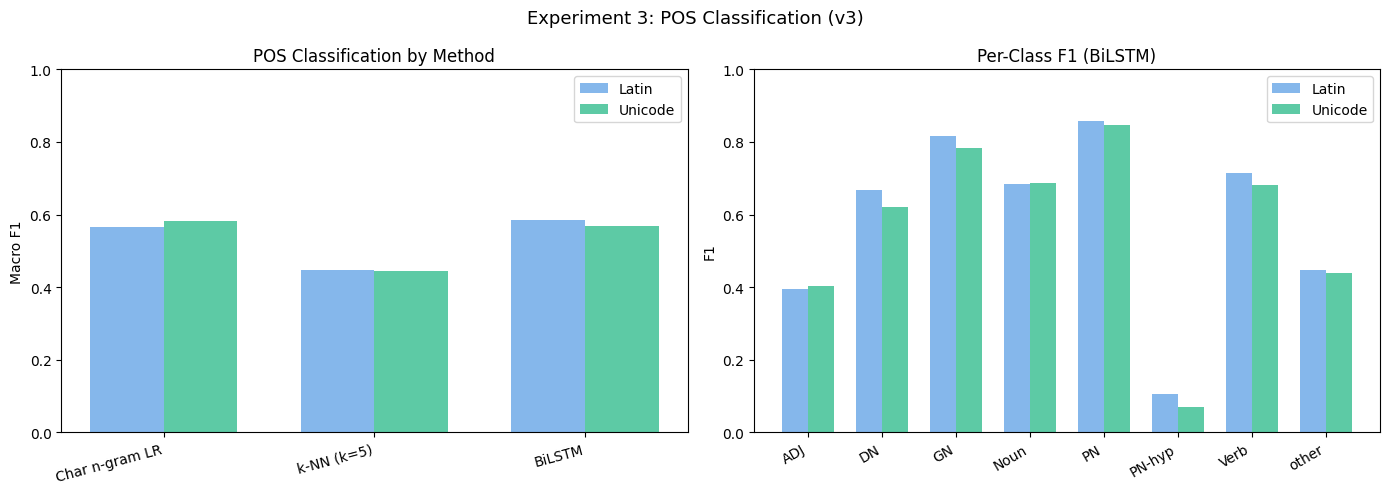

In [19]:
# ============================================================
# 4f. COMPARISON PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Method comparison
methods = ['Char n-gram LR', 'k-NN (k=5)', 'BiLSTM']
# Collect k-NN scores
knn_l = cross_val_score(
    ImbPipeline([('smote', SMOTE(random_state=SEED, k_neighbors=min(5, min_class_l-1))),
                 ('clf', KNeighborsClassifier(n_neighbors=5, metric='cosine'))]),
    X_l, y_l, cv=cv, scoring='f1_macro'
).mean()
knn_u = cross_val_score(
    ImbPipeline([('smote', SMOTE(random_state=SEED, k_neighbors=min(5, min_class_u-1))),
                 ('clf', KNeighborsClassifier(n_neighbors=5, metric='cosine'))]),
    X_u, y_u, cv=cv, scoring='f1_macro'
).mean()

latin_scores = [ngram_f1_l, knn_l, bilstm_f1_l]
unicode_scores = [ngram_f1_u, knn_u, bilstm_f1_u]

x = np.arange(len(methods)); w = 0.35
axes[0].bar(x-w/2, latin_scores, w, label='Latin', color='#85B7EB')
axes[0].bar(x+w/2, unicode_scores, w, label='Unicode', color='#5DCAA5')
axes[0].set_xticks(x); axes[0].set_xticklabels(methods, rotation=15, ha='right')
axes[0].set_ylabel('Macro F1'); axes[0].set_title('POS Classification by Method')
axes[0].legend(); axes[0].set_ylim(0, 1)

# Per-class F1 for BiLSTM
labels_enc = le.transform(clf_data['category'].tolist())
pcl = f1_score(labels_enc, bilstm_pred_l, labels=range(n_classes), average=None, zero_division=0)
pcu = f1_score(labels_enc, bilstm_pred_u, labels=range(n_classes), average=None, zero_division=0)
x2 = np.arange(n_classes)
axes[1].bar(x2-w/2, pcl, w, label='Latin', color='#85B7EB')
axes[1].bar(x2+w/2, pcu, w, label='Unicode', color='#5DCAA5')
axes[1].set_xticks(x2); axes[1].set_xticklabels(le.classes_, rotation=30, ha='right')
axes[1].set_ylabel('F1'); axes[1].set_title('Per-Class F1 (BiLSTM)')
axes[1].legend(); axes[1].set_ylim(0, 1)

plt.suptitle('Experiment 3: POS Classification (v3)', fontsize=13)
plt.tight_layout(); plt.savefig('exp3_pos_v3.png', dpi=150, bbox_inches='tight'); plt.show()

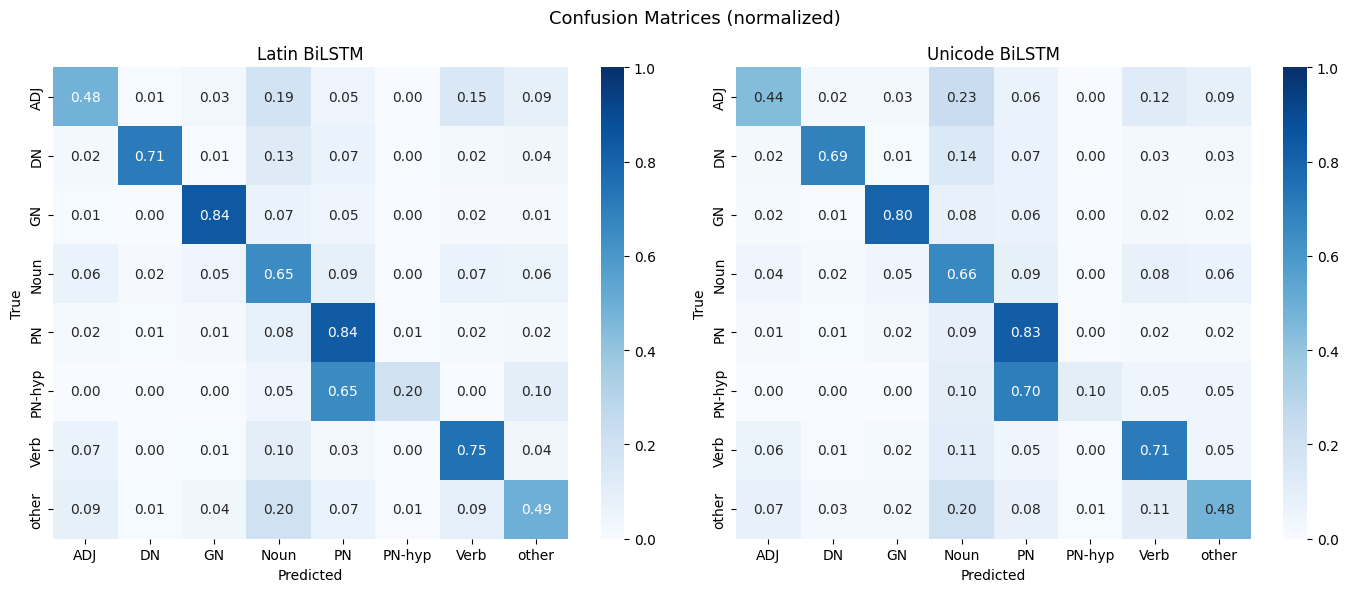

In [20]:
# ============================================================
# 5. CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, preds, title in [(axes[0], bilstm_pred_l, 'Latin BiLSTM'),
                          (axes[1], bilstm_pred_u, 'Unicode BiLSTM')]:
    cm = confusion_matrix(labels_enc, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=le.classes_,
                yticklabels=le.classes_, cmap='Blues', ax=ax, vmin=0, vmax=1)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Confusion Matrices (normalized)', fontsize=13)
plt.tight_layout(); plt.savefig('exp3_confusion_v3.png', dpi=150, bbox_inches='tight'); plt.show()

In [21]:
# ============================================================
# 6. FINAL SUMMARY
# ============================================================
print('=' * 70)
print('RESULTS SUMMARY (v3)')
print('=' * 70)
print(f'Data: {len(dict_clean)} entries ({len(dict_clean)/len(to_unicode)*100:.1f}% conversion)')
print(f'Nasu: {len(nasu_df)} tokens, {len(docs_unicode)} docs')
print()
print('Exp 1: Embeddings')
print(f'  Silhouette:         Latin={sil_l:.4f}  Unicode={sil_u:.4f}')
print(f'  Morpheme coherence: Latin={coh_l:.4f}  Unicode={coh_u:.4f}')
print(f'  Per-class silhouette winners:')
for cat in sorted(pc_l.keys()):
    w = 'U' if pc_u.get(cat,0) > pc_l[cat] else 'L'
    print(f'    {cat}: {w}')
print()
print('Exp 2: Word Boundaries')
print(f'  TP:  P={best_tp["precision"]:.3f} R={best_tp["recall"]:.3f} F1={best_tp["f1"]:.3f}')
print(f'  BPE: P={np.mean([s[0] for s in bpe_scores]):.3f} R={np.mean([s[1] for s in bpe_scores]):.3f} '
      f'F1={np.mean([s[2] for s in bpe_scores]):.3f}')
print()
print('Exp 3: POS Classification (Macro-F1)')
print(f'  Char n-gram LR: Latin={ngram_f1_l:.3f}  Unicode={ngram_f1_u:.3f}')
print(f'  k-NN (k=5):     Latin={knn_l:.3f}  Unicode={knn_u:.3f}')
print(f'  BiLSTM:          Latin={bilstm_f1_l:.3f}  Unicode={bilstm_f1_u:.3f}')
print('=' * 70)

RESULTS SUMMARY (v3)
Data: 13383 entries (85.8% conversion)
Nasu: 2582 tokens, 85 docs

Exp 1: Embeddings
  Silhouette:         Latin=-0.0342  Unicode=-0.0612
  Morpheme coherence: Latin=0.6377  Unicode=0.6483
  Per-class silhouette winners:
    ADJ: L
    DN: U
    GN: U
    Noun: L
    PN: L
    PN-hyp: L
    Verb: L
    other: L

Exp 2: Word Boundaries
  TP:  P=0.987 R=1.000 F1=0.993
  BPE: P=0.989 R=0.995 F1=0.991

Exp 3: POS Classification (Macro-F1)
  Char n-gram LR: Latin=0.567  Unicode=0.582
  k-NN (k=5):     Latin=0.447  Unicode=0.446
  BiLSTM:          Latin=0.586  Unicode=0.568
